### Exploration of correlations between escape genes/pathways and clinical data/biomarkers

We have identified that one of the most affected pathways is ECM remodelling, and genes involved in its formation are among escape ones. Additionally, one of the strongest escape genes is Serpine1, which is a regulator of the fibrinolytic system (inhitor). 

Numerous studies have established PAI-1 as the primary inhibitor of the fibrinolytic system by regulating the expressions of tissue-type plasminogen activator (tPA) and urokinase-type plasminogen activator (uPA), these enzymes facilitate the transformation of plasminogen into plasmin the enzyme responsible for degrading fibrin in blood clots.

Question: do we see traces of those changes in the blood biomarkers?

In [32]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from matplotlib.patches import Patch
from pathlib import Path

PROJECT_ROOT = Path("/Users/achechenina/projects/centenerians")

### CIAO Biomarkers

Data prep:

In [33]:
to_plot_blood_full = ['AZOTEMIA ', 'GLICE', 'SODIUM', 'POTASSIUM', 'CREATININE', 'GFR ', 'COLESTHEROL. TOTAL', 'HDL-C', 'LDL -C', 'TRIGLYCERIDES',
                'URICEMIA', 'AST', 'ALT', 'BILIRUBINE', 'GAMMA GT', 'HB. FREE', 'HB A1C', 'HB. GLICOSILATED', 'HB A0', 'PRO BNP', 'CRP',
                'ProThrombine', 'ALBUM', 'ALFA1', 'ALFA2', 'BETA1', 'BETA2', 'GAMMA', 'RATIO', 'ALBUMG', 'ALFA1G', 'ALFA2G', 'BETA1G', 'BETA2G',
                'GAMMA G', 'WBC', 'RBC', 'HGB', 'HCT', 'MCH C', 'MCH', 'MCV', 'RDW',
                'NEUTROPHILES', 'EOSI N', 'BASOFILES', 'LINFOCYTES', 'MONOCYTES', 'PLATELETS', 'MPV']
to_plot_blood_interest = ['CRP',  # inflammation
                        'ProThrombine', 'PLATELETS', 'MPV',  # coagulation
                        'TRIGLYCERIDES', 'HDL-C',  # metabolic and insulin resistance
                        'GAMMA GT']  # liver function

EDA_PLOT_DIR = PROJECT_ROOT / "results/plots/EDA_clinical"
PROT_TSV = PROJECT_ROOT / "data/proteomics/20251119_124929_P1921_P1958_Protein_Quant_Report_WH_111925.tsv"

meta_full = pd.read_csv(PROJECT_ROOT / "results/040726_meta_combined.csv", low_memory=False)
ciao_ukbb_classified = pd.read_csv(PROJECT_ROOT / "results/data/escape_analysis/ukbb_centenarian_overlap_classified.csv")
escape_ciao = set(ciao_ukbb_classified.loc[ciao_ukbb_classified['Category'] == 'Escape', 'Gene'].astype(str))
prots_counts = pd.read_csv(PROJECT_ROOT / "results/data/proteomics_log2_standartized_5208.csv")

# Gene labels in the same row order as `prots_counts` (5208 × samples)
prot_raw = pd.read_csv(PROT_TSV, sep='\t', low_memory=False)
_abundance_cols = [c for c in prot_raw.columns if str(c).endswith('.PG.Quantity')]
_feature_ok = prot_raw[_abundance_cols].isna().sum(axis=1) == 0
prot_labeled = prot_raw.loc[_feature_ok, ['PG.Genes']].reset_index(drop=True)
assert len(prot_labeled) == len(prots_counts), 'Protein table row count mismatch'


def _gene_tokens(pg_genes):
    if pd.isna(pg_genes):
        return frozenset()
    return frozenset(t.strip() for t in str(pg_genes).replace(';', ' ').split() if t.strip())


def escape_row_mask(pg_series, escape_set):
    esc_up = {g.upper() for g in escape_set}
    mask = []
    for g in pg_series:
        toks = {t.upper() for t in _gene_tokens(g)}
        mask.append(bool(toks & esc_up))
    return np.array(mask, dtype=bool)


escape_mask = escape_row_mask(prot_labeled['PG.Genes'], escape_ciao)

# Long table: one row per sample with proteomics + group + labs
meta_px = meta_full.loc[meta_full['Prot_Col'].isin(prots_counts.columns)].copy()
group_col = 'Condition' if meta_px['Condition'].nunique() >= 2 else 'Lab_Group'
meta_px.head()


,Prot_Col,File_Name,Condition,Batch,Full_ID,Sample_Num,Match_ID,Is_Technical_Replicate,Lab_Group,Creatinine,...,MONOCYTES,Normoblasts count,NEUTR absolute number,EOSI absolute number,BASOF absolute number,LINFO absolute number,MONOCYTE absolute number,Nuclear red blood cells absolute number,PLATELETS,MPV
0,[1] P001921_smp_DIA_AB1.raw.PG.Quantity,P001921_smp_DIA_AB1,Centenarian,P001921,10810705022,1.0,5022,False,Centenarian,1.10,...,9.6,NST,2570.0,150.0,40.0,1270.0,430.0,NST,237000.0,11.6
1,[2] P001921_smp_DIA_AB2.raw.PG.Quantity,P001921_smp_DIA_AB2,Centenarian,P001921,10810705155,2.0,5155,False,Centenarian,1.17,...,8.6,NST,2950.0,190.0,20.0,1850.0,470.0,NST,175000.0,11.2
2,[3] P001921_smp_DIA_AB3.raw.PG.Quantity,P001921_smp_DIA_AB3,Centenarian,P001921,10810705324,3.0,5324,False,Centenarian,0.96,...,6.9,NST,4130.0,110.0,20.0,2270.0,490.0,NST,171000.0,10.1
3,[4] P001921_smp_DIA_AB4.raw.PG.Quantity,P001921_smp_DIA_AB4,Centenarian,P001921,10810705326,4.0,5326,False,Centenarian,0.96,...,11.2,NST,3840.0,200.0,30.0,1900.0,750.0,NST,170000.0,10.6
4,[5] P001921_smp_DIA_AB5.raw.PG.Quantity,P001921_smp_DIA_AB5,Centenarian,P001921,10810705987,5.0,5987,False,Centenarian,2.30,...,6.5,NST,4320.0,200.0,20.0,1120.0,390.0,NST,204000.0,9.2


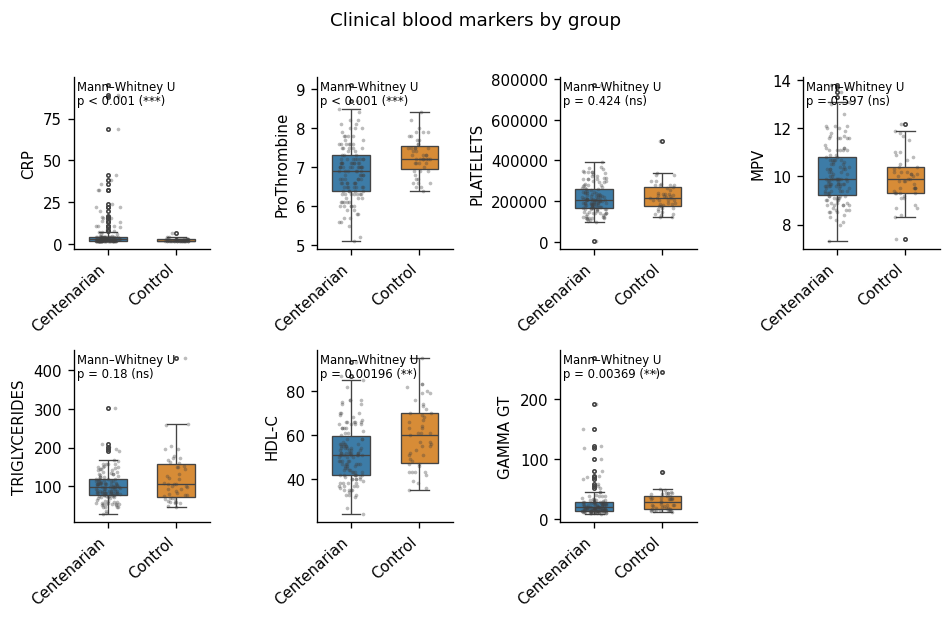

In [34]:
EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'axes.titleweight': 'normal',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

palette = {'Centenarian': '#2c7fb8', 'Control': '#f28e1c'}
order = [g for g in ['Centenarian', 'Control'] if g in set(meta_px[group_col])]

rows = []
for _, r in meta_px.iterrows():
    row = {'Prot_Col': r['Prot_Col'], 'Group': r[group_col]}
    for lab in to_plot_blood_interest:
        row[lab] = pd.to_numeric(r.get(lab), errors='coerce')
    rows.append(row)
plot_df = pd.DataFrame(rows)

n = len(to_plot_blood_interest)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 2.5 * nrows), sharey=False)
axes = np.atleast_2d(axes).ravel()


def _mannwhitney_two_group(sub, group_col, lab, g0, g1):
    v0 = sub.loc[sub[group_col] == g0, lab].to_numpy(dtype=float)
    v1 = sub.loc[sub[group_col] == g1, lab].to_numpy(dtype=float)
    v0 = v0[np.isfinite(v0)]
    v1 = v1[np.isfinite(v1)]
    if v0.size < 2 or v1.size < 2:
        return np.nan
    try:
        _, p = scipy.stats.mannwhitneyu(v0, v1, alternative='two-sided')
    except ValueError:
        return np.nan
    return float(p)


def _sig_stars(p):
    if not np.isfinite(p):
        return ''
    if p > 0.05:
        return 'ns'
    if p > 0.01:
        return '*'
    if p > 0.001:
        return '**'
    return '***'


for ax, lab in zip(axes, to_plot_blood_interest):
    sub = plot_df[['Group', lab]].dropna()
    sns.boxplot(
        data=sub, x='Group', y=lab, hue='Group', order=order, hue_order=order,
        palette=palette, dodge=False, width=0.55, linewidth=0.8, ax=ax, fliersize=2, legend=False,
    )
    sns.stripplot(data=sub, x='Group', y=lab, order=order, color='0.25', size=2.2, alpha=0.35, ax=ax, dodge=False, jitter=0.18)
    ax.set_xlabel('')
    ax.set_ylabel(lab)
    plt.setp(ax.get_xticklabels(), rotation=42, ha='right')

    p = np.nan
    if len(order) == 2:
        p = _mannwhitney_two_group(sub, 'Group', lab, order[0], order[1])
    if np.isfinite(p):
        st = _sig_stars(p)
        if p < 1e-4:
            p_txt = 'p < 1e-4'
        elif p < 0.001:
            p_txt = 'p < 0.001'
        else:
            p_txt = f'p = {p:.3g}'
        ax.text(0.02, 0.98, f'Mann–Whitney U\n{p_txt} ({st})', transform=ax.transAxes, ha='left', va='top', fontsize=7, linespacing=1.05)

for j in range(len(to_plot_blood_interest), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Clinical blood markers by group', y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig(EDA_PLOT_DIR / 'clinical_interest_by_group_boxplots.png', bbox_inches='tight')
#fig.savefig(EDA_PLOT_DIR / 'clinical_interest_by_group_boxplots.pdf', bbox_inches='tight')
plt.show()

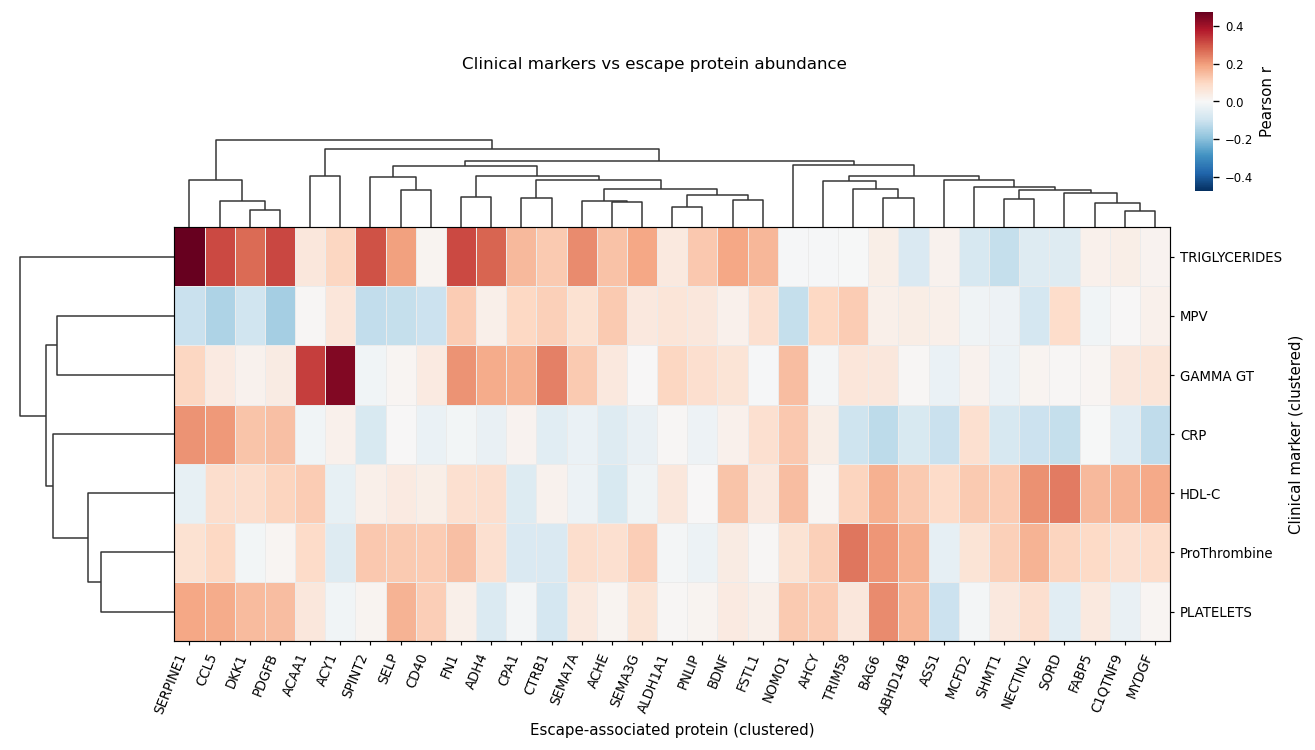

In [35]:
# Sample-aligned matrix: columns = Prot_Col order in proteomics
sample_cols = list(prots_counts.columns)
X = prots_counts[sample_cols].to_numpy(dtype=float)
meta_ord = meta_px.set_index('Prot_Col').reindex(sample_cols)
clinical_mat = np.column_stack([pd.to_numeric(meta_ord[c], errors='coerce').to_numpy() for c in to_plot_blood_interest])
clinical_labels = list(to_plot_blood_interest)

# Escape proteins only (subset rows)
X_esc = X[escape_mask, :]
esc_genes_for_plot = prot_labeled.loc[escape_mask, 'PG.Genes'].tolist()
# Short labels: first gene symbol in PG.Genes string
esc_short = [str(g).split(';')[0].strip()[:18] for g in esc_genes_for_plot]

# Pearson correlation: each clinical vs each escape protein (across samples)
r_mat = np.full((clinical_mat.shape[1], X_esc.shape[0]), np.nan, dtype=float)
for i in range(clinical_mat.shape[1]):
    x = clinical_mat[:, i]
    for j in range(X_esc.shape[0]):
        y = X_esc[j, :]
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 8:
            continue
        r_mat[i, j], _ = scipy.stats.pearsonr(x[m], y[m])

vlim = float(np.nanmax(np.abs(r_mat)))
if not np.isfinite(vlim) or vlim < 0.08:
    vlim = 0.3

# Unique column names (first gene token can repeat across protein groups)
uniq_esc = []
_seen = {}
for s in esc_short:
    base = str(s)[:22]
    k = _seen.get(base, 0)
    _seen[base] = k + 1
    uniq_esc.append(base if k == 0 else f'{base}.{k}')

r_df = pd.DataFrame(r_mat, index=clinical_labels, columns=uniq_esc)
# Hierarchical clustering does not accept NaN; missing pairs are rare here
r_plot = r_df.fillna(0.0)

_n_clin, n_esc = r_plot.shape
fig_w = max(7.8, 0.26 * n_esc + 2.4)
fig_h = max(4.5, 0.42 * _n_clin + 2.8)

# Colorbar in figure coordinates [left, bottom, width, height] — narrow vertical strip, upper right.
# (Seaborn sets cbar_pos internally, then `subplots_adjust` below resets layout; we re-apply with set_position.)
CBAR_RECT = [0.91, 0.8, 0.014, 0.26]

g = sns.clustermap(
    r_plot,
    cmap='RdBu_r',
    center=0.0,
    vmin=-vlim,
    vmax=vlim,
    metric='euclidean',
    method='average',
    figsize=(fig_w, fig_h),
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(0.14, 0.18),
    colors_ratio=0.02,
    cbar_pos=CBAR_RECT,
    linewidths=0.35,
    linecolor='0.92',
    xticklabels=True,
    yticklabels=True,
    tree_kws=dict(linewidths=0.9),
    cbar_kws=dict(label='Pearson r', shrink=0.85),
    rasterized=True,
)
hm = g.ax_heatmap
hm.set_xlabel('Escape-associated protein (clustered)')
hm.set_ylabel('Clinical marker (clustered)')
hm.set_xticklabels(hm.get_xticklabels(), rotation=68, ha='right', fontsize=7)
hm.set_yticklabels(hm.get_yticklabels(), rotation=0, fontsize=8)
hm.tick_params(axis='both', which='both', length=2.5, width=0.7, labelsize=8)
for sp in hm.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.7)

g.ax_row_dendrogram.set_visible(True)
g.ax_col_dendrogram.set_visible(True)
g.cax.set_ylabel('Pearson r', fontsize=9)

g.fig.suptitle(
    'Clinical markers vs escape protein abundance',
    fontsize=10,
    y=0.995,
)
g.fig.subplots_adjust(top=0.88)
if g.cax is not None:
    g.cax.set_position(CBAR_RECT)
    g.cax.tick_params(labelsize=7)
    g.cax.yaxis.set_label_position('right')
    g.cax.yaxis.tick_right()

out_base = EDA_PLOT_DIR / 'clinical_vs_escape_proteins_correlation_clustermap'
if g.cax is not None:
    g.cax.set_position(CBAR_RECT)
g.savefig(f'{out_base}.png', dpi=300, bbox_inches='tight', facecolor='white')
#g.savefig(f'{out_base}.pdf', bbox_inches='tight', facecolor='white')
plt.show()

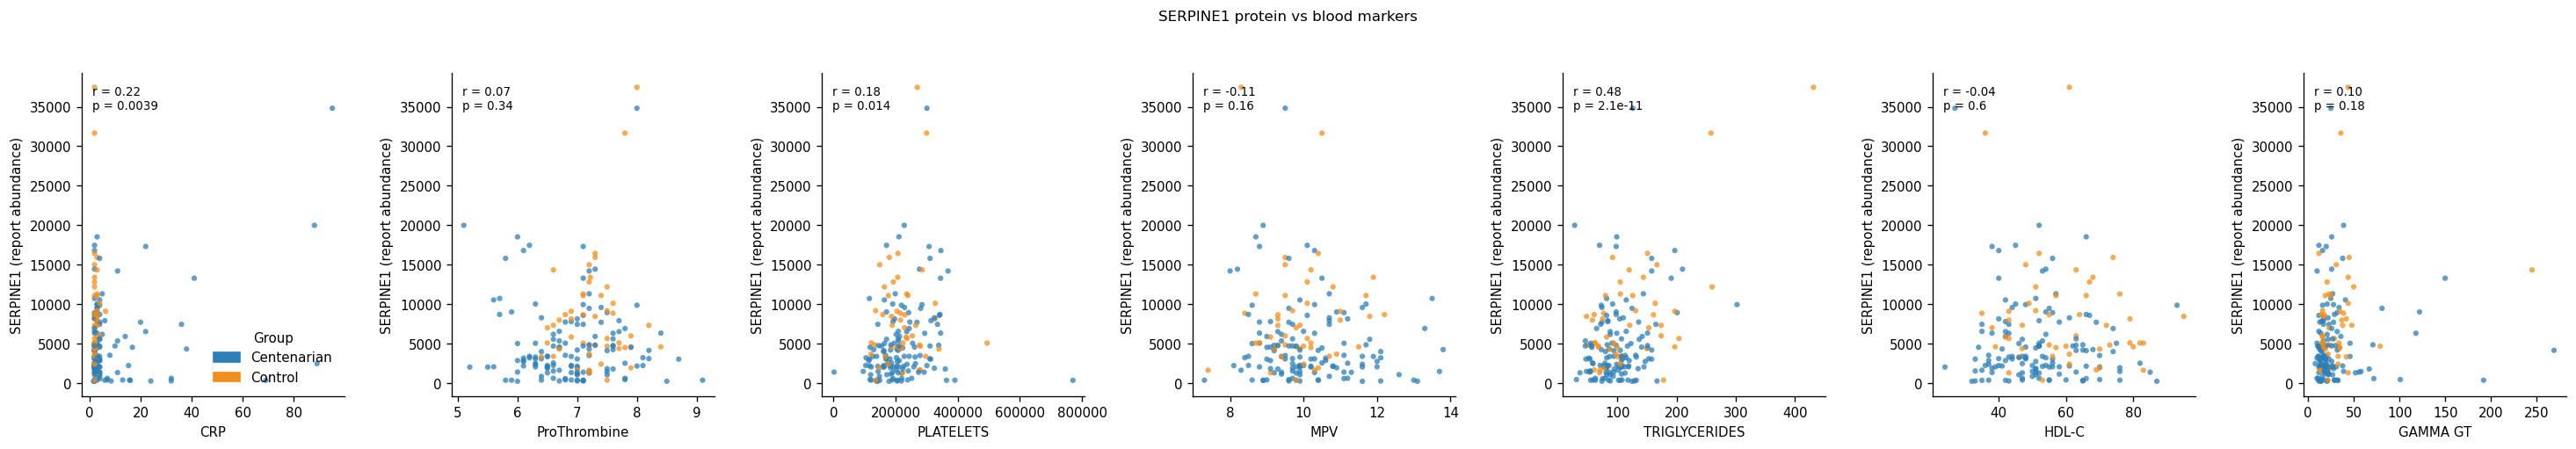

In [36]:
# Highlight: SERPINE1 (PAI-1) vs coagulation / inflammation readouts
serp_idx = None
for k, g in enumerate(prot_labeled['PG.Genes']):
    if 'SERPINE1' in str(g).upper():
        serp_idx = k
        break

if serp_idx is not None:
    y_ser = prots_counts.iloc[serp_idx][sample_cols].to_numpy(dtype=float)
    fig, axes = plt.subplots(1, len(to_plot_blood_interest), figsize=(3.5 * len(to_plot_blood_interest), 4))
    # If len == 1, axes isn't iterable; coerce to list for downstream code
    if len(to_plot_blood_interest) == 1:
        axes = [axes]
    for ax, lab in zip(axes, to_plot_blood_interest):
        x = pd.to_numeric(meta_ord[lab], errors='coerce').to_numpy()
        # Align both x and y_ser to same index; filter for finite both
        m = np.isfinite(x) & np.isfinite(y_ser)
        group_vals = meta_ord[group_col].values
        colors = np.array([palette.get(g, '#555555') for g in group_vals])[m]
        ax.scatter(x[m], y_ser[m], c=colors, s=14, alpha=0.75, edgecolors='none')
        if m.sum() >= 8:
            r, p = scipy.stats.pearsonr(x[m], y_ser[m])
            ax.text(0.04, 0.96, f"r = {r:.2f}\np = {p:.2g}", transform=ax.transAxes, va='top', fontsize=8)
        ax.set_xlabel(lab)
        ax.set_ylabel('SERPINE1 (report abundance)')
        sns.despine(ax=ax)
    handles = [Patch(color=palette[g], label=g) for g in order if g in palette]
    axes[0].legend(handles=handles, loc='lower right', title='Group')
    fig.suptitle('SERPINE1 protein vs blood markers', y=1.05, fontsize=10)
    fig.tight_layout()
    fig.savefig(EDA_PLOT_DIR / 'serpine1_vs_blood_markers.png', bbox_inches='tight')
    #fig.savefig(EDA_PLOT_DIR / 'serpine1_vs_crp_platelets.pdf', bbox_inches='tight')
    plt.show()
else:
    print('SERPINE1 not found in protein table')

### NECS biomarkers

In [ ]:
nec_biomarkers = pd.read_excel("/Users/achechenina/projects/centenerians/data/New_England_Sebastiani/acel13290-sup-0001-appendixs1/acel13290-sup-0002-TableS1.xlsx",
sheet_name="Supplement table 1b", index_col=0)
nec_biomarkers.head()

,Official name,Uniprot,FC.cont2cent,Adj.Pvalue
TAME Candidate Biomarker of Aging,,,,
Adiponectin,ADIPQ,Q15848,0.810916,0.000445
α-fetoprotein ( AFP ),AFP,P02771,0.854652,0.000034
Receptor for advanced glycation endproducts,AGER (RAGE),Q15109,0.812968,0.038588
Akt,AKT1 AKT2 AKT3,P31749 P31751 Q9Y243,0.823547,0.002358
Albumin,Albumin,P02768,1.016973,0.857941


In [44]:
significant_biom

,Official name,Uniprot,FC.cont2cent,Adj.Pvalue
TAME Candidate Biomarker of Aging,,,,
Adiponectin,ADIPQ,Q15848,0.810916,4.445520e-04
α-fetoprotein ( AFP ),AFP,P02771,0.854652,3.448240e-05
Receptor for advanced glycation endproducts,AGER (RAGE),Q15109,0.812968,3.858761e-02
Akt,AKT1 AKT2 AKT3,P31749 P31751 Q9Y243,0.823547,2.357638e-03
APOA,apoa1,P02647,1.196382,1.490410e-07
Beta-amyloid,APP,P05067,1.061856,2.218411e-02
Beta 2 microglobulin,B2M,P61769,0.529434,6.786000e-20
C- Reactive Protein (CRP),CRP,P02741,0.624354,1.333431e-02
Cystatin C,CST3,P01034,0.618404,6.519560e-18


Significant in cent-controls comparison (p < 0.05 and |logFC| > 0.5):


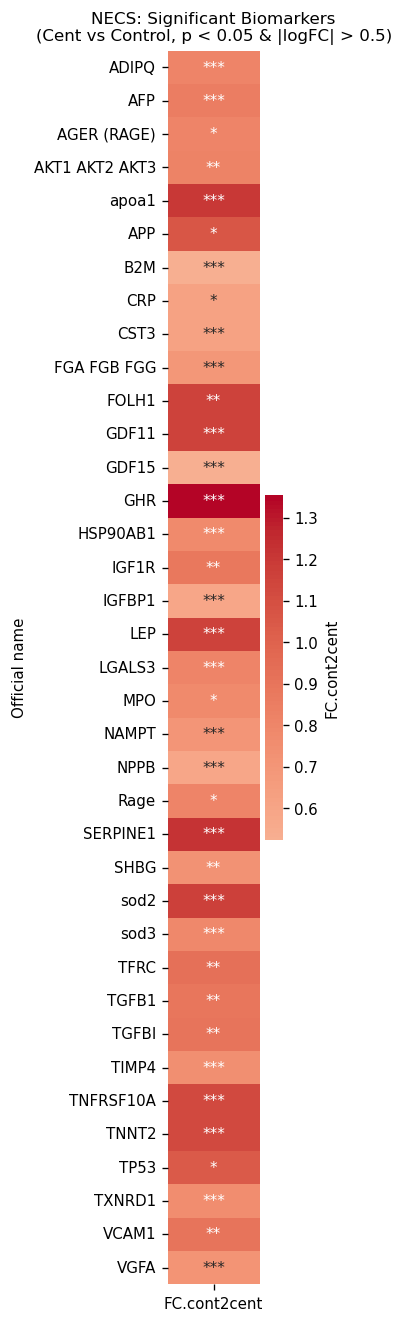

In [43]:
print('Significant in cent-controls comparison (p < 0.05 and |logFC| > 0.5):')
significant_biom = nec_biomarkers[(nec_biomarkers['FC.cont2cent'].abs() > 0.5) & (nec_biomarkers['Adj.Pvalue'] < 0.05)]

# Prepare data for heatmap: FC.cont2cent, with Official name as rows
fc_vals = significant_biom.set_index("Official name")[['FC.cont2cent']]

# Create a significance mark for Adj.Pvalue < 0.05
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''
significance = significant_biom['Adj.Pvalue'].apply(significance_stars)
significance.index = significant_biom['Official name']

plt.figure(figsize=(3, max(4, 0.3*fc_vals.shape[0])))
ax = sns.heatmap(fc_vals, annot=significance.values.reshape(-1,1), fmt='', center=0, cmap="coolwarm", cbar_kws={'label': 'FC.cont2cent'})
ax.set_ylabel("Official name")
ax.set_title("NECS: Significant Biomarkers\n(Cent vs Control, p < 0.05 & |logFC| > 0.5)")
plt.tight_layout()
plt.show()